# Model
model.py

In [1]:
import torch
import torch.nn as nn
from typing import Tuple, List

class FinancialVAE(nn.Module):
    
    def __init__(
        self, 
        n_stock: int,
        window: int,
        hidden_dims: List[int] = [128, 64],
        dropout: float = 0.25,
        activation: str = 'elu'
    ):
        super(FinancialVAE, self).__init__()
        
        self.input_dim = n_stock * window + window
        self.window = window

        self.activation = self._get_activation(activation)
        self.hidden = self._build_hidden(hidden_dims, dropout)
        
        self.alpha_embedder = nn.Linear(hidden_dims[-1], n_stock)
        self.beta_embedder  = nn.Linear(hidden_dims[-1], n_stock)
    
    def _get_activation(self, activation: str) -> nn.Module:
        activations = {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'selu': nn.SELU(),
            'leaky_relu': nn.LeakyReLU(0.2)
        }
        return activations.get(activation.lower(), nn.ELU())
    
    def _build_hidden(self, hidden_dims: List[int], dropout: float) -> nn.Sequential:
        layers = []
        prev_dim = self.input_dim
        
        for h_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(self.activation)
            layers.append(nn.Dropout(dropout))
            prev_dim = h_dim
        
        return nn.Sequential(*layers)
    
    def forward(self, X: torch.Tensor, r_market: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        h = self.hidden(X)
        
        alpha = self.alpha_embedder(h)
        beta  = self.beta_embedder(h)

        reconstruction = alpha + beta * r_market.unsqueeze(-1)
        reconstruction = reconstruction.transpose(-2, -1).flatten(start_dim=-2)
        
        """
        DEPRICATED
        r_market = r_market.unsqueeze(1)
        reconstruction = alpha + beta * r_market

        # Keep the shape [n_stock * window] insted of [window, n_stock]
        reconstruction = reconstruction.T.flatten()
        """
        return reconstruction, alpha, beta

# Data
data.py

In [2]:
import torch
from torch.utils.data import Dataset

class SyntheticLogReturnsDataset(Dataset):
    def __init__(self, n_stock=None, t=None, window=None, distribution='normal', 
                 include_market=False, overlapping_windows=False, task='reconstruction', seed=42):
        """
        Args:
            n_stock: Number of stocks
            t: Number of dataset samples
            window: Window size
            distribution: 'normal' or 't'
            include_market: Whether to include market returns in features
            overlapping_windows: If False (default), windows don't overlap. If True, windows overlap.
            task: 'reconstruction' or 'prediction'
                  - 'reconstruction': model recreates input returns
                  - 'prediction': model predicts next return(s) after the window
            seed: Random seed
        """
        self.n_stock = n_stock
        self.t = t
        self.window = window
        self.distribution = distribution
        self.include_market = include_market
        self.overlapping_windows = overlapping_windows
        self.task = task
        self.seed = seed
        
        if n_stock is not None and t is not None and window is not None:
            self._generate_data()
    
    def _generate_data(self):
        torch.manual_seed(self.seed)
        
        # Calculate total time points needed
        if self.overlapping_windows:
            # Overlapping: need t + window - 1
            t_total = self.t + self.window - 1
        else:
            # Non-overlapping: need t * window
            t_total = self.t * self.window

        if self.task == 'prediction':
                t_total += 1
        
        # SPY 20-year mean = 0.0003, std = 0.0122
        self.r_market = self._generate_returns(t_total, self.distribution, mean=0.0003, std=0.0122)
        self.alphas = torch.randn(self.n_stock) * 0.005
        self.betas = torch.randn(self.n_stock) * 0.3 + 1.0
        self.idio_vols = torch.rand(self.n_stock) * 0.015 + 0.005
        
        r_systematic = self.alphas.unsqueeze(1) + self.betas.unsqueeze(1) * self.r_market.unsqueeze(0)
        idio_noise = self._generate_returns((self.n_stock, t_total), self.distribution)
        idio_noise = idio_noise * self.idio_vols.unsqueeze(1)
        self.returns = r_systematic + idio_noise
        
        self._precompute_windows()
    
    def _generate_returns(self, shape, distribution, mean=0.0, std=1.0):
        if distribution == 'normal':
            return torch.randn(shape) * std + mean
        elif distribution == 't':
            dist = torch.distributions.studentT.StudentT(df=5.0)
            samples = dist.sample(shape if isinstance(shape, tuple) else (shape,))
            return samples * std / (5/3)**0.5 + mean
        else:
            raise ValueError(f"Unknown distribution: {distribution}")
    
    def _precompute_windows(self):
        windows = []
        targets = []
        markets = []
        
        for i in range(self.t):
            if self.overlapping_windows:
                start_idx = i
                end_idx = i + self.window
            else:
                start_idx = i * self.window
                end_idx = (i + 1) * self.window
            
            # Collect stock windows
            stock_windows = []
            for stock_idx in range(self.n_stock):
                stock_window = self.returns[stock_idx, start_idx:end_idx]
                stock_windows.append(stock_window)
            
            stock_data = torch.cat(stock_windows)
            
            # Add market data if requested
            if self.include_market:
                market_window = self.r_market[start_idx:end_idx]
                window_data = torch.cat([stock_data, market_window])

                if self.task == 'prediction':
                    markets.append(self.r_market[end_idx].unsqueeze(0))
                else:
                    markets.append(market_window)
            else:
                window_data = stock_data
            
            windows.append(window_data)
            
            # Prepare targets for prediction task
            if self.task == 'prediction':
                target_idx = end_idx  # Next time step after the window
                targets.append(self.returns[:, target_idx])
            else:
                targets.append(stock_data)
        
        self.windowed_data = torch.stack(windows)
        self.targets = torch.stack(targets)
        self.markets = torch.stack(markets)
    
    def __len__(self):
        return self.t
    
    def __getitem__(self, idx):
        if isinstance(idx, slice):
            indices = range(*idx.indices(len(self)))
            selection = list(indices)
        else:
            selection = idx

        X = self.windowed_data[selection]
        y = self.targets[selection]
        m = self.markets[selection]
        
        return X, y, m
    
    def partition_stocks(self, n_partitions):
        """Partition dataset into subsets by stock while sharing the same market returns."""
        stocks_per_partition = self.n_stock // n_partitions
        partitions = []
        
        for i in range(n_partitions):
            start_stock = i * stocks_per_partition
            end_stock = start_stock + stocks_per_partition if i < n_partitions - 1 else self.n_stock
            
            partition = SyntheticLogReturnsDataset()
            partition.n_stock = end_stock - start_stock
            partition.t = self.t
            partition.window = self.window
            partition.distribution = self.distribution
            partition.include_market = self.include_market
            partition.overlapping_windows = self.overlapping_windows
            partition.task = self.task
            partition.seed = self.seed
            
            partition.r_market = self.r_market
            partition.alphas = self.alphas[start_stock:end_stock]
            partition.betas = self.betas[start_stock:end_stock]
            partition.idio_vols = self.idio_vols[start_stock:end_stock]
            partition.returns = self.returns[start_stock:end_stock]
            
            partition._precompute_windows()
            partitions.append(partition)
        
        return partitions

def generate_datasets(config):
    seed_start = config['SEED']
    seed_end   = seed_start + config['N_DATASET_TRAIN']
    
    train_datasets = [
        SyntheticLogReturnsDataset(
            n_stock        = config['N_STOCK'],
            t              = config['T'],
            window         = config['WINDOW'],
            distribution   = config['DISTRIBUTION'],
            task           = config['TASK'],
            include_market = True,
            overlapping_windows=False,
            seed           = seed
        ) for seed in range(seed_start, seed_end)
    ]
    
    seed_start = seed_end
    seed_end   = seed_start + config['N_DATASET_VAL']
    
    val_datasets = [
        SyntheticLogReturnsDataset(
            n_stock        = config['N_STOCK'],
            t              = config['T'],
            window         = config['WINDOW'],
            distribution   = config['DISTRIBUTION'],
            task           = config['TASK'],
            include_market = True,
            overlapping_windows=False,
            seed           = seed
        ) for seed in range(seed_start, seed_end)
    ]
    
    seed_start = seed_end
    seed_end   = seed_start + config['N_DATASET_TEST']
    
    test_datasets = [
        SyntheticLogReturnsDataset(
            n_stock        = config['N_STOCK'],
            t              = config['T'],
            window         = config['WINDOW'],
            distribution   = config['DISTRIBUTION'],
            task           = config['TASK'],
            include_market = True,
            overlapping_windows=False,
            seed           = seed
        ) for seed in range(seed_start, seed_end)
    ]

    return train_datasets, val_datasets, test_datasets

In [30]:
dataset = SyntheticLogReturnsDataset(
    n_stock=10,
    t=1000, 
    window=60, 
    distribution='normal', 
    include_market=True, 
    overlapping_windows=False, 
    task='reconstruction',
    seed=42
)

model = FinancialVAE(n_stock=10, window=60)

# Main
main.py

In [3]:
import time
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset
from torch.utils.tensorboard import SummaryWriter

#from data import SyntheticLogReturnsDataset
#from model import FinancialVAE

In [4]:
def config2str(config: dict):
    config_str = ""
    for key in config:
        config_str += f"{key:>20s}: {config[key]}\n"
    
    return config_str

def run_model(config, log_dir='runs/tmp'):
    writer = SummaryWriter(log_dir=log_dir)
    writer.add_text('hparams', config2str(config))

In [ ]:
config = {
    'N_DATASET_TRAIN': 100,
    'N_DATASET_VAL': 20,
    'N_DATASET_TEST': 10,
    'N_STOCK': 10,
    'T': 1000,
    'WINDOW': 60,
    'TASK': 'prediction',
    'HIDDEN_DIMS': [1024, 512],
    'BATCH_SIZE': 1,           # Modify?
    'NUM_EPOCHS': 4,
    'LEARNING_RATE': 1e-4,
    'SHUFFLE_BATCHES': True,
    'DROPOUT': 0.25,
    'PATIENCE': 5,
    'ACTIVATION': 'elu',
    'DISTRIBUTION': 'normal',
    'SEED': 45
}

start_time = time.time()

train_datasets, val_datasets, test_datasets = generate_datasets(config)

train_loader = DataLoader(ConcatDataset(train_datasets), batch_size=config['BATCH_SIZE'], shuffle=config['SHUFFLE_BATCHES'])
val_loader   = DataLoader(ConcatDataset(val_datasets),   batch_size=config['BATCH_SIZE'], shuffle=False)
test_loader  = DataLoader(ConcatDataset(test_datasets),  batch_size=1, shuffle=False)

print(f"Generated datasets in {time.time() - start_time:>7f} seconds!")

model = FinancialVAE(
    n_stock = config['N_STOCK'],
    window = config['WINDOW'],
    hidden_dims = config['HIDDEN_DIMS'],
    dropout = config['DROPOUT'],
    activation = config['ACTIVATION']
)

optimizer = torch.optim.Adam(model.parameters(), lr=config['LEARNING_RATE'])
loss_function = nn.MSELoss(reduction='mean')

# Init tracking variables
train_loss = []
val_loss = []
start_time = time.time()
sample_freq = config['T'] // config['BATCH_SIZE']

for epoch in range(1, config['NUM_EPOCHS'] + 1):
    print(f"Epoch {epoch}\n-------------------------------")

    model.train()
    for batch, (X, y, m) in enumerate(train_loader, start=1):
        
        reconstruction, alpha, beta = model(X, m)
        
        loss = loss_function(reconstruction, y)
        
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % sample_freq == 0:
            train_loss.append(loss.item())
            print(f"loss: {loss:>7f}  [{batch:>6d}/{len(train_loader):>6d}]  t={time.time() - start_time:>9.3f}s")

    model.eval()
    with torch.no_grad():
        val_loss_sum = 0
        for batch, (X, y, m) in enumerate(val_loader, start=1):
            
            reconstruction, alpha, beta = model(X, m)
            
            loss = loss_function(reconstruction, y)
            val_loss_sum += loss.item()

            if batch % sample_freq == 0:
                val_loss.append(val_loss_sum / sample_freq)
                val_loss_sum = 0

    val_loss_mean = np.mean(val_loss[-config['N_DATASET_VAL']])
    print(f"Validation Error: \n Avg loss: {val_loss_mean:>8f}  t={time.time() - start_time:>9.3f}s\n")
    
print("Done!")

# Benchmark

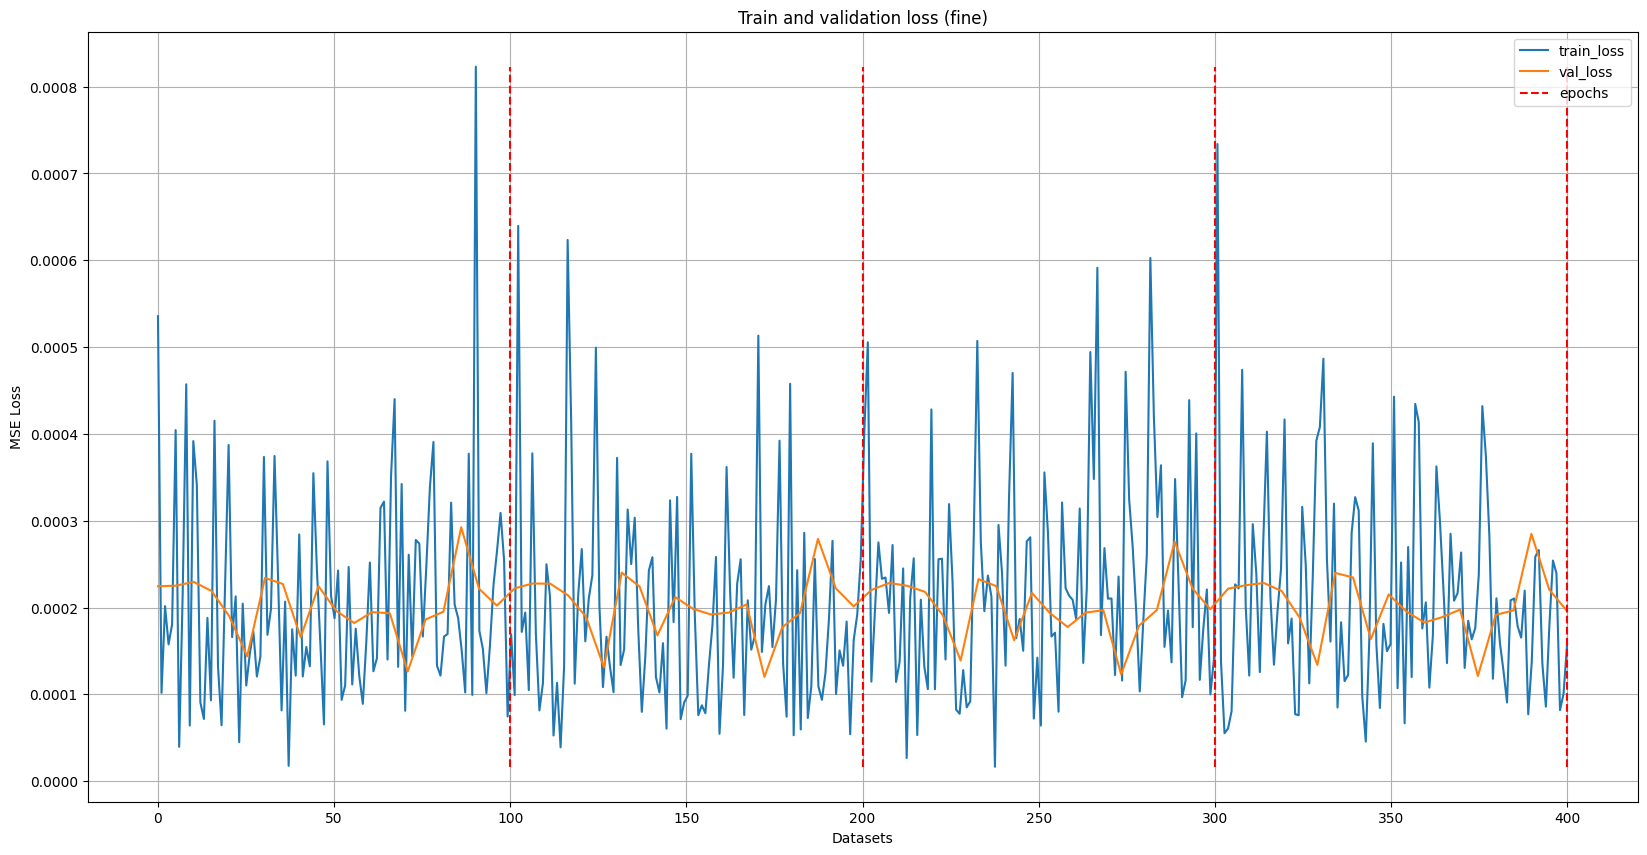

In [6]:
plt.figure(figsize=(20, 10))
plt.plot(np.linspace(0, 400, 400), train_loss, label='train_loss')
plt.plot(np.linspace(0, 400, 80), val_loss, label='val_loss')
plt.vlines([100, 200, 300, 400], np.min(train_loss), np.max(train_loss), colors='red', linestyles='dashed', label='epochs')
plt.title('Train and validation loss (fine)')
plt.xlabel('Datasets')
plt.ylabel('MSE Loss')
plt.grid()
plt.legend()
plt.show()

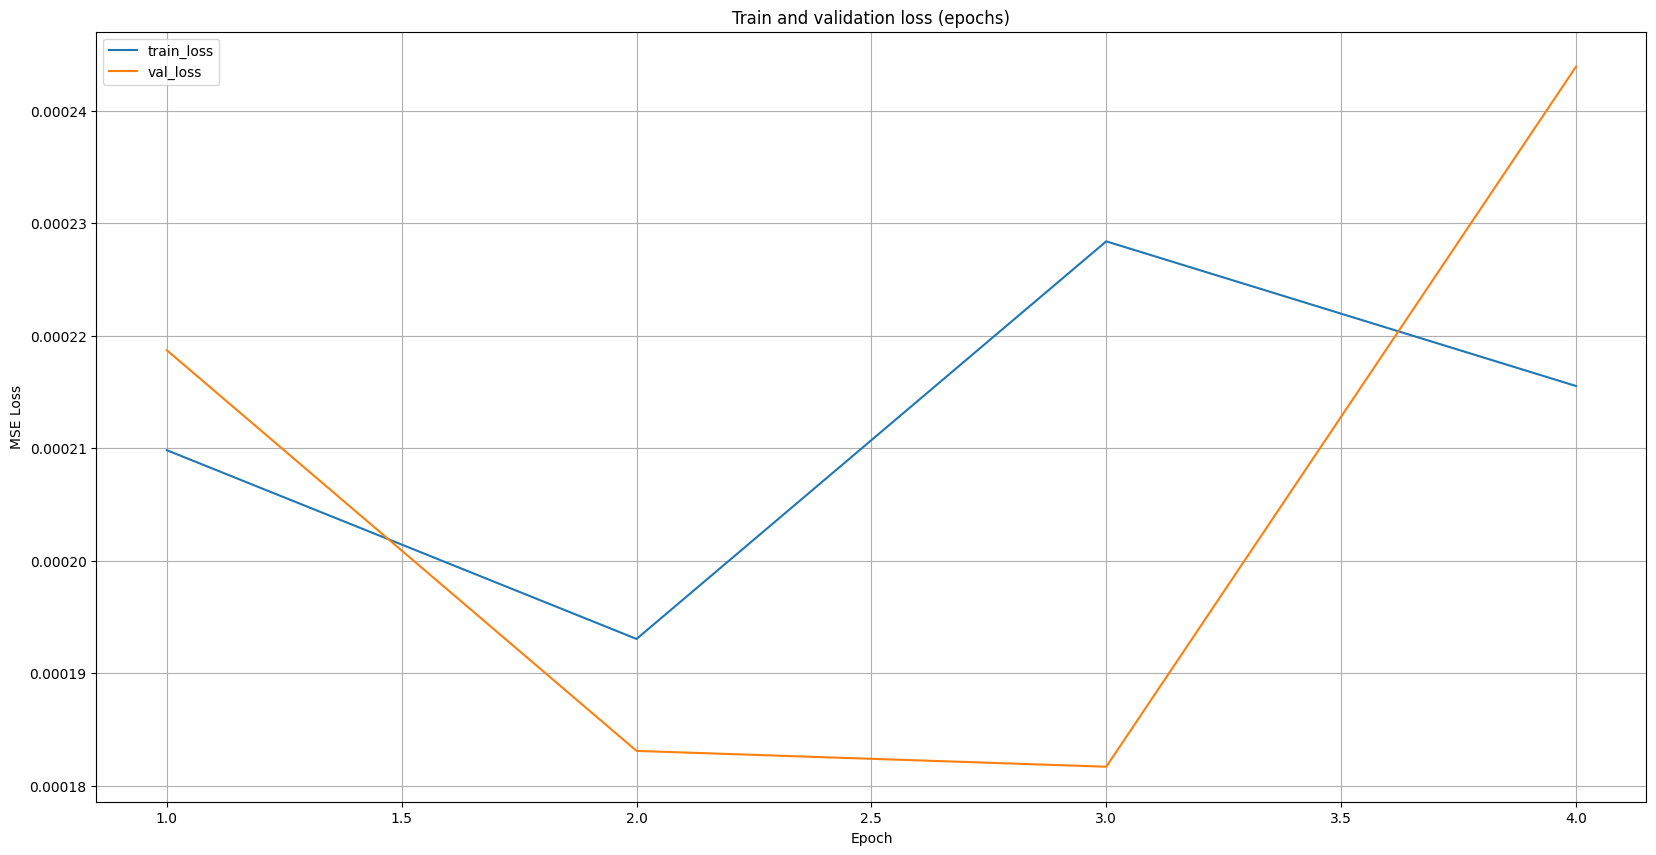

In [7]:
train_loss_epoch = [np.mean(train_loss[start:start + config['N_DATASET_TRAIN']]) for start in range(0, config['NUM_EPOCHS'] * config['N_DATASET_TRAIN'], config['N_DATASET_TRAIN'])]
val_loss_epoch = [np.mean(train_loss[start:start + config['N_DATASET_VAL']]) for start in range(0, config['NUM_EPOCHS'] * config['N_DATASET_VAL'], config['N_DATASET_VAL'])]
x = list(range(1, config['NUM_EPOCHS'] + 1))

plt.figure(figsize=(20, 10))
plt.plot(x, train_loss_epoch, label='train_loss')
plt.plot(x, val_loss_epoch, label='val_loss')
plt.title('Train and validation loss (epochs)')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.grid()
plt.legend()
plt.show()

In [8]:
from scipy import stats

def OLS_on_sample(X, m, config):
    alphas = []
    betas = []

    r = X[:-config['WINDOW']]
    r_market = X[-config['WINDOW']:]
    
    for r_stock in r.reshape(config['N_STOCK'], config['WINDOW']):
        beta, alpha, _, _, _ = stats.linregress(r_market, r_stock)
        alphas.append(alpha)
        betas.append(beta)
    
    alpha = torch.Tensor(alphas)
    beta = torch.Tensor(betas)
    
    reconstruction = alpha + beta * m

    return reconstruction, alpha, beta

true_alphas = torch.stack([test_dataset.alphas for test_dataset in test_datasets])
true_betas  = torch.stack([test_dataset.betas for test_dataset in test_datasets])

loss_function = nn.MSELoss(reduction='mean')

model_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

ols_summary = {
    'recon_loss': [],
    'alpha_loss': [],
    'beta_loss':[],
    'alpha': [],
    'beta': []
}

sample_freq = config['T'] // config['BATCH_SIZE']

model_alpha, model_beta = [], []
ols_alpha, ols_beta = [], []

i = 0
true_alpha = true_alphas[i]
true_beta  = true_betas[i]

model.eval()
with torch.no_grad():
    for batch, (X, y, m) in enumerate(test_loader, start=1):
        
        # Model loss
        reconstruction, alpha, beta = model(X, m)
        model_summary['recon_loss'].append(loss_function(reconstruction, y).item())
        model_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        model_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        model_alpha.append(alpha.detach())
        model_beta.append(beta.detach())

        
        #OLS and OLS loss
        X, y, m = X.squeeze(), y.squeeze(), m.squeeze()
        
        reconstruction, alpha, beta = OLS_on_sample(X, m, config)
        ols_summary['recon_loss'].append(loss_function(reconstruction, y).item())
        ols_summary['alpha_loss'].append(loss_function(alpha, true_alpha).item())
        ols_summary['beta_loss'].append(loss_function(beta, true_beta).item())

        ols_alpha.append(alpha)
        ols_beta.append(beta)

        
        if batch % sample_freq == 0:
            i += 1
            if i < len(true_alphas) and i < len(true_betas):
                true_alpha = true_alphas[i]
                true_beta  = true_betas[i]

            model_summary['alpha'].append(torch.stack(model_alpha))
            model_summary['beta'].append(torch.stack(model_beta))

            ols_summary['alpha'].append(torch.stack(ols_alpha))
            ols_summary['beta'].append(torch.stack(ols_beta))
            
            model_alpha, model_beta = [], []
            ols_alpha, ols_beta = [], []


# TODO Fix model apha and beta shapes
model_summary['alpha'] = torch.cat(model_summary['alpha'], dim=1).T
model_summary['beta'] = torch.cat(model_summary['beta'], dim=1).T

ols_summary['alpha'] = torch.cat(ols_summary['alpha'], dim=1).T
ols_summary['beta'] = torch.cat(ols_summary['beta'], dim=1).T

/home/marko/Environments/python/fer/dipl/lib/python3.12/site-packages/torch/nn/modules/loss.py:634: UserWarning: Using a target size (torch.Size([10])) that is different to the input size (torch.Size([1, 10])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/tmp/ipykernel_668149/3084296288.py:95: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4416.)
  model_summary['alpha'] = torch.cat(model_summary['alpha'], dim=1).T


In [9]:
model_summary['alpha'] = model_summary['alpha'].flatten(0, 1)
model_summary['beta'] = model_summary['beta'].flatten(0, 1)

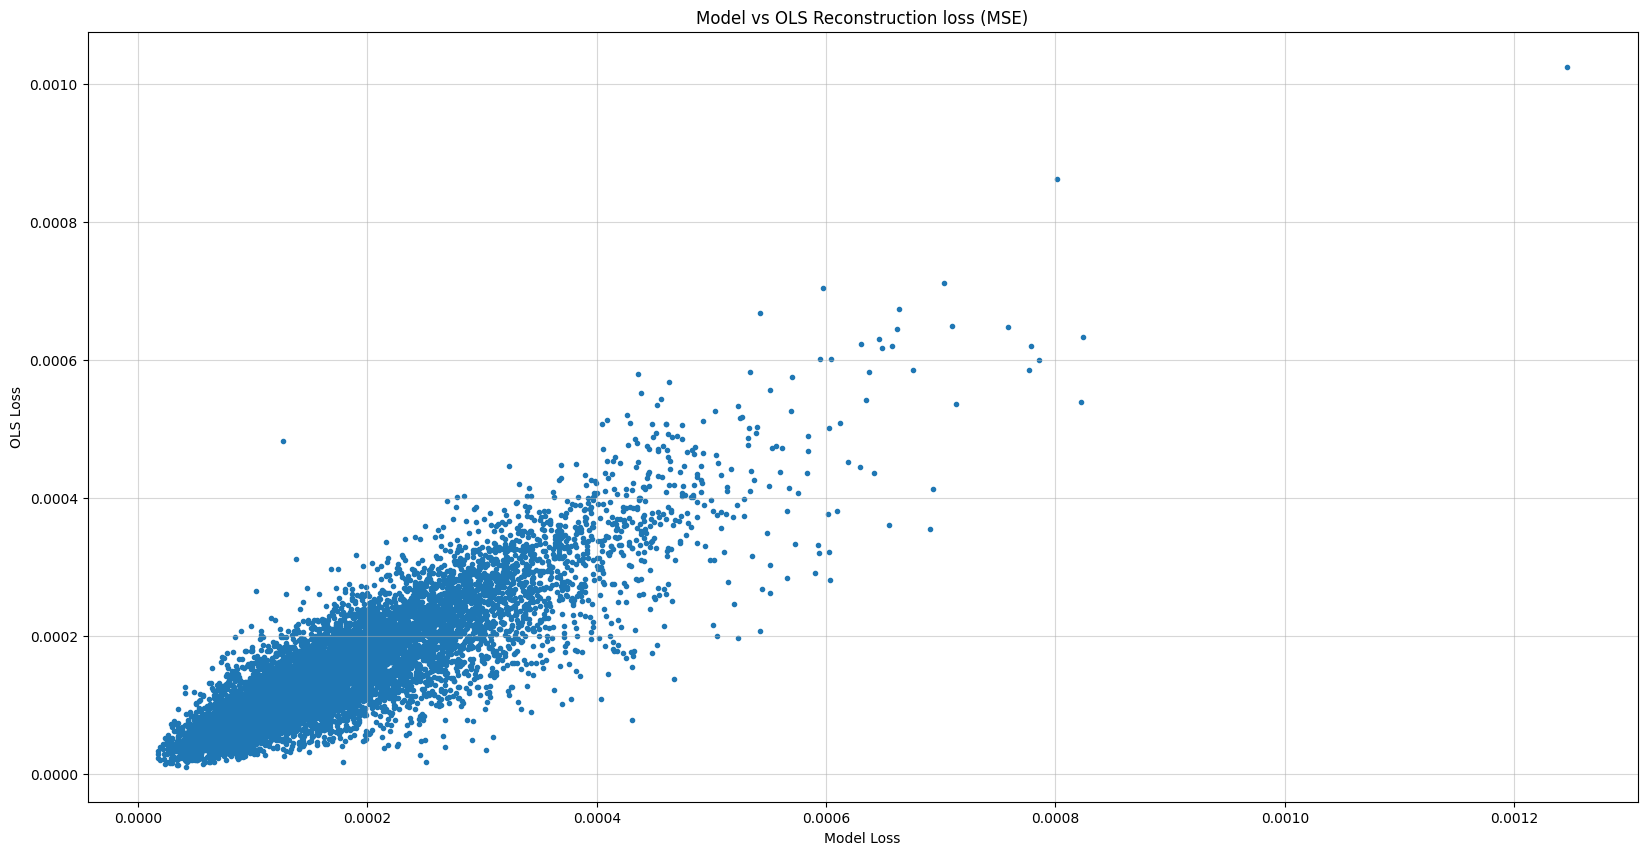

In [10]:
plt.figure(figsize=(20, 10))

plt.scatter(model_summary['recon_loss'], ols_summary['recon_loss'], marker='.')
plt.xlabel('Model Loss')
plt.ylabel('OLS Loss')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)
plt.show()

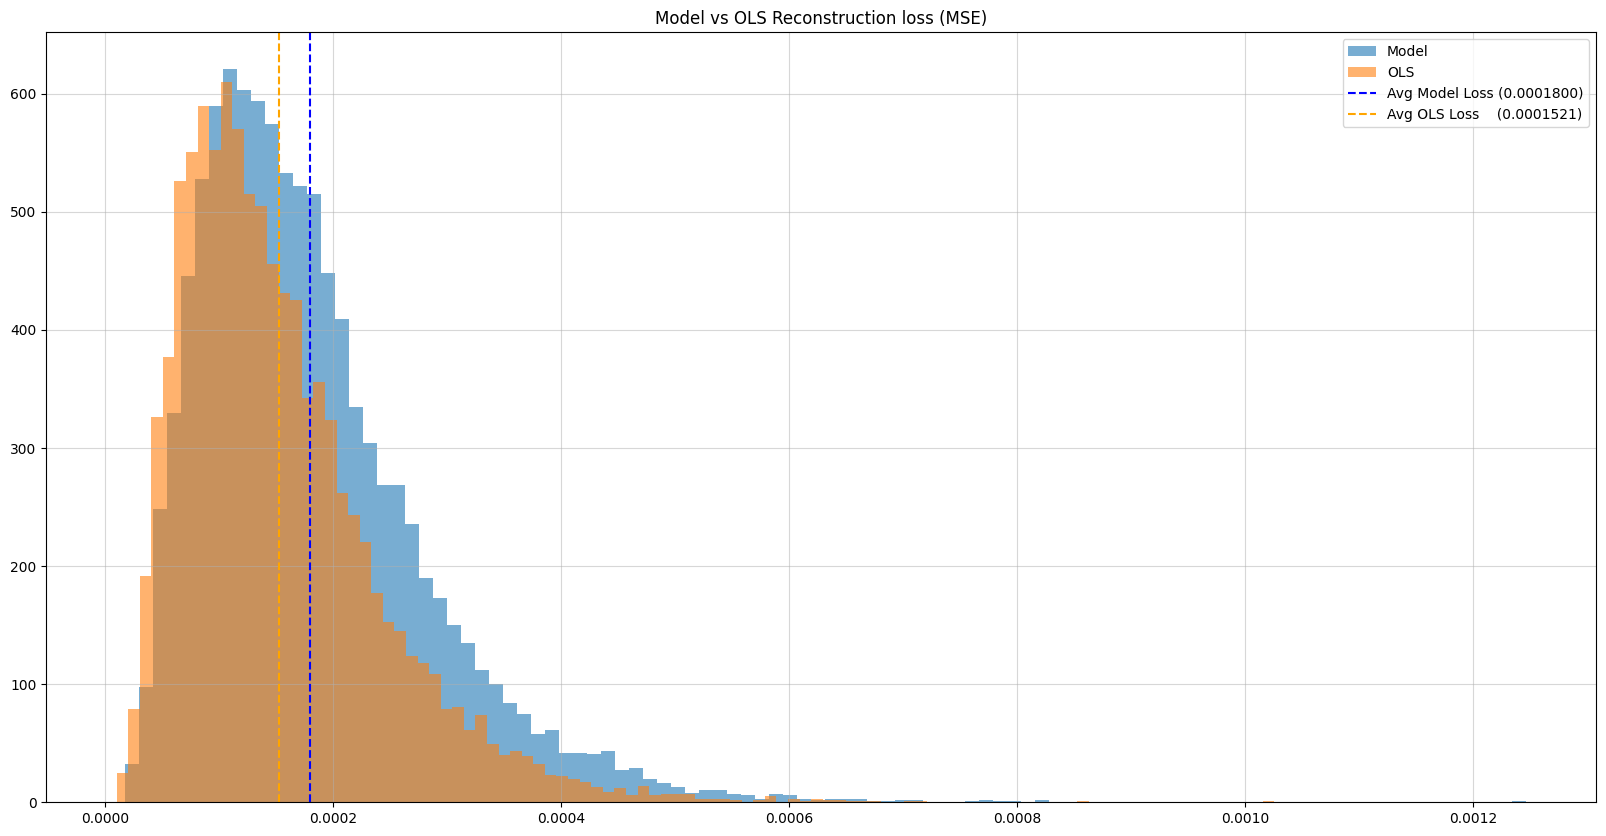

In [11]:
model_train_loss = np.mean(model_summary['recon_loss'])
ols_train_loss = np.mean(ols_summary['recon_loss'])

plt.figure(figsize=(20, 10))

plt.hist(model_summary['recon_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['recon_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_train_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_train_loss:.7f})')
plt.axvline(ols_train_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_train_loss:.7f})')

plt.title('Model vs OLS Reconstruction loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

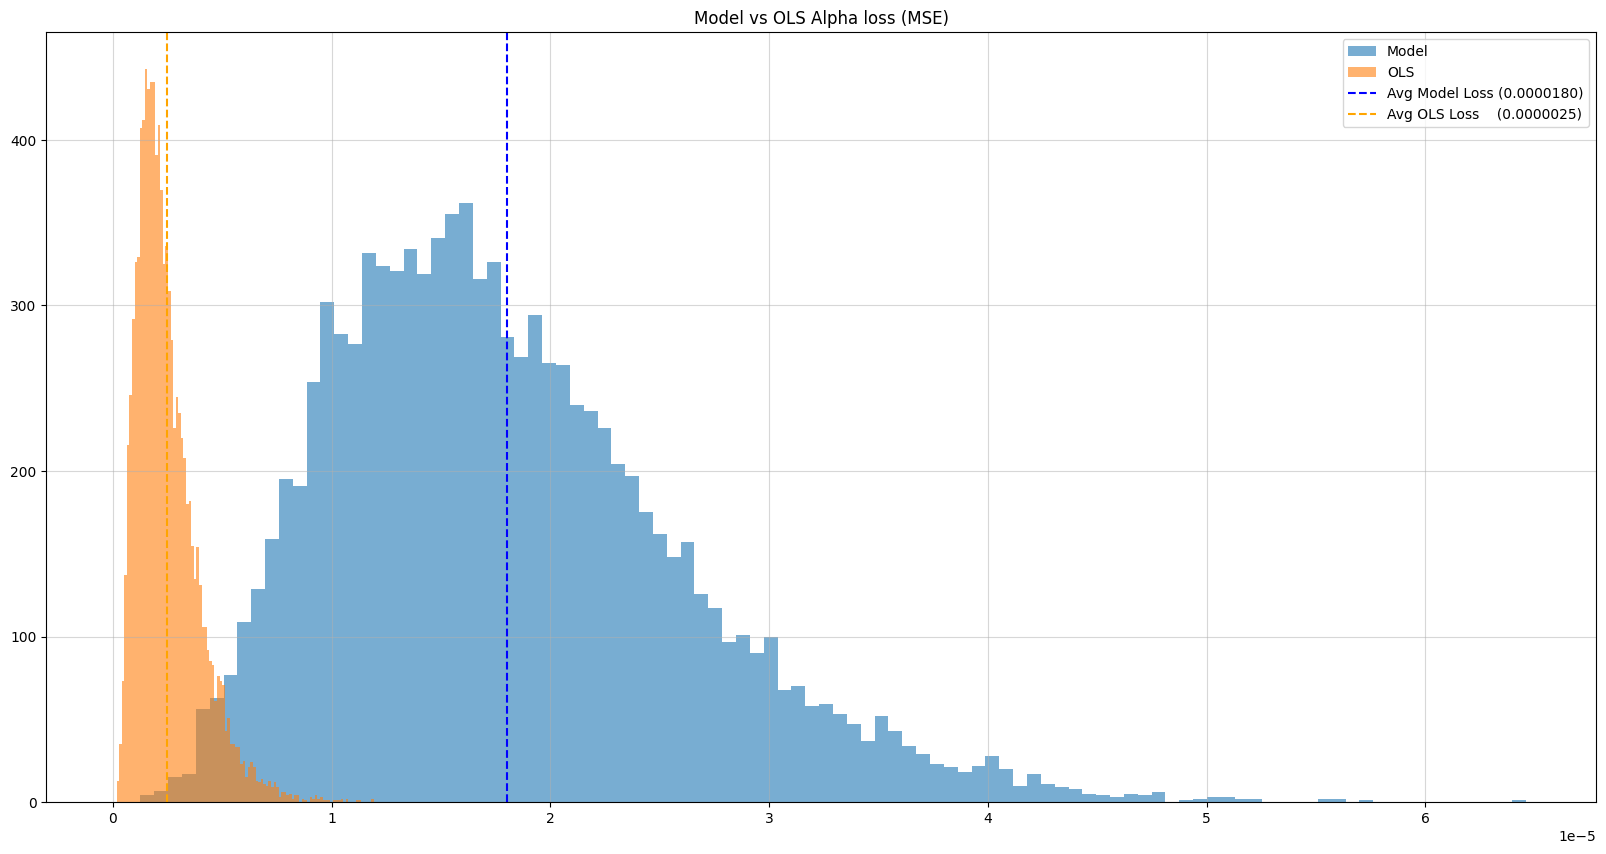

In [12]:
model_alpha_train_loss = np.mean(model_summary['alpha_loss'])
ols_alpha_train_loss = np.mean(ols_summary['alpha_loss'])

plt.figure(figsize=(20, 10))

plt.hist(model_summary['alpha_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['alpha_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_alpha_train_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_alpha_train_loss:.7f})')
plt.axvline(ols_alpha_train_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_alpha_train_loss:.7f})')

plt.title('Model vs OLS Alpha loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

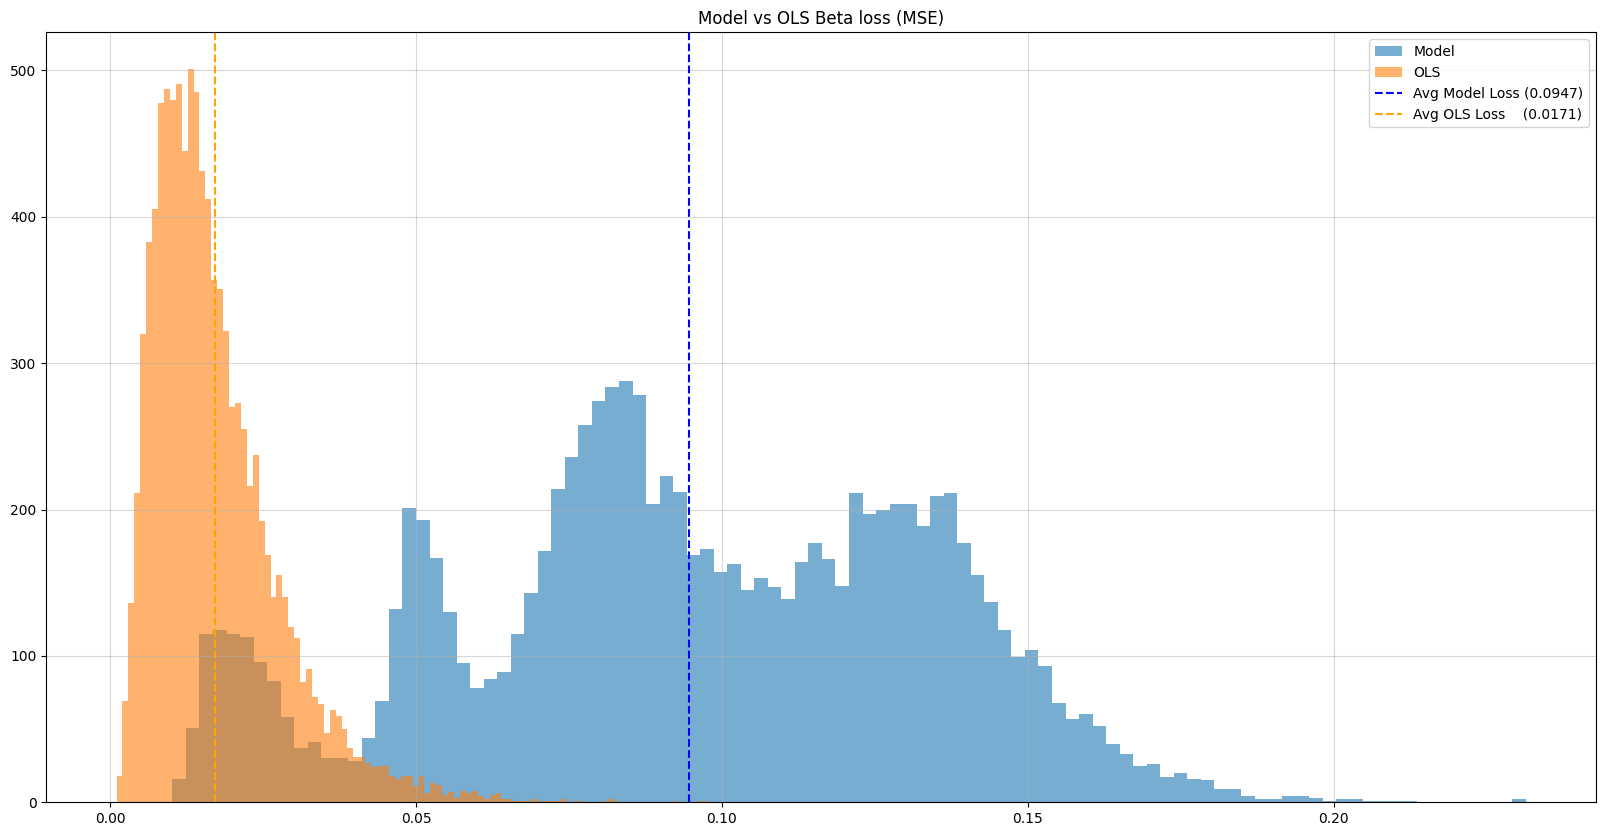

In [13]:
model_beta_train_loss = np.mean(model_summary['beta_loss'])
ols_beta_train_loss = np.mean(ols_summary['beta_loss'])

plt.figure(figsize=(20, 10))

plt.hist(model_summary['beta_loss'], bins=100, alpha=0.6, label='Model')
plt.hist(ols_summary['beta_loss'], bins=100, alpha=0.6, label='OLS')

plt.axvline(model_beta_train_loss, color='blue', linestyle='--', label=f'Avg Model Loss ({model_beta_train_loss:.4f})')
plt.axvline(ols_beta_train_loss, color='orange', linestyle='--', label=f'Avg OLS Loss    ({ols_beta_train_loss:.4f})')

plt.title('Model vs OLS Beta loss (MSE)')
plt.grid(alpha=0.5)
plt.legend()
plt.show()

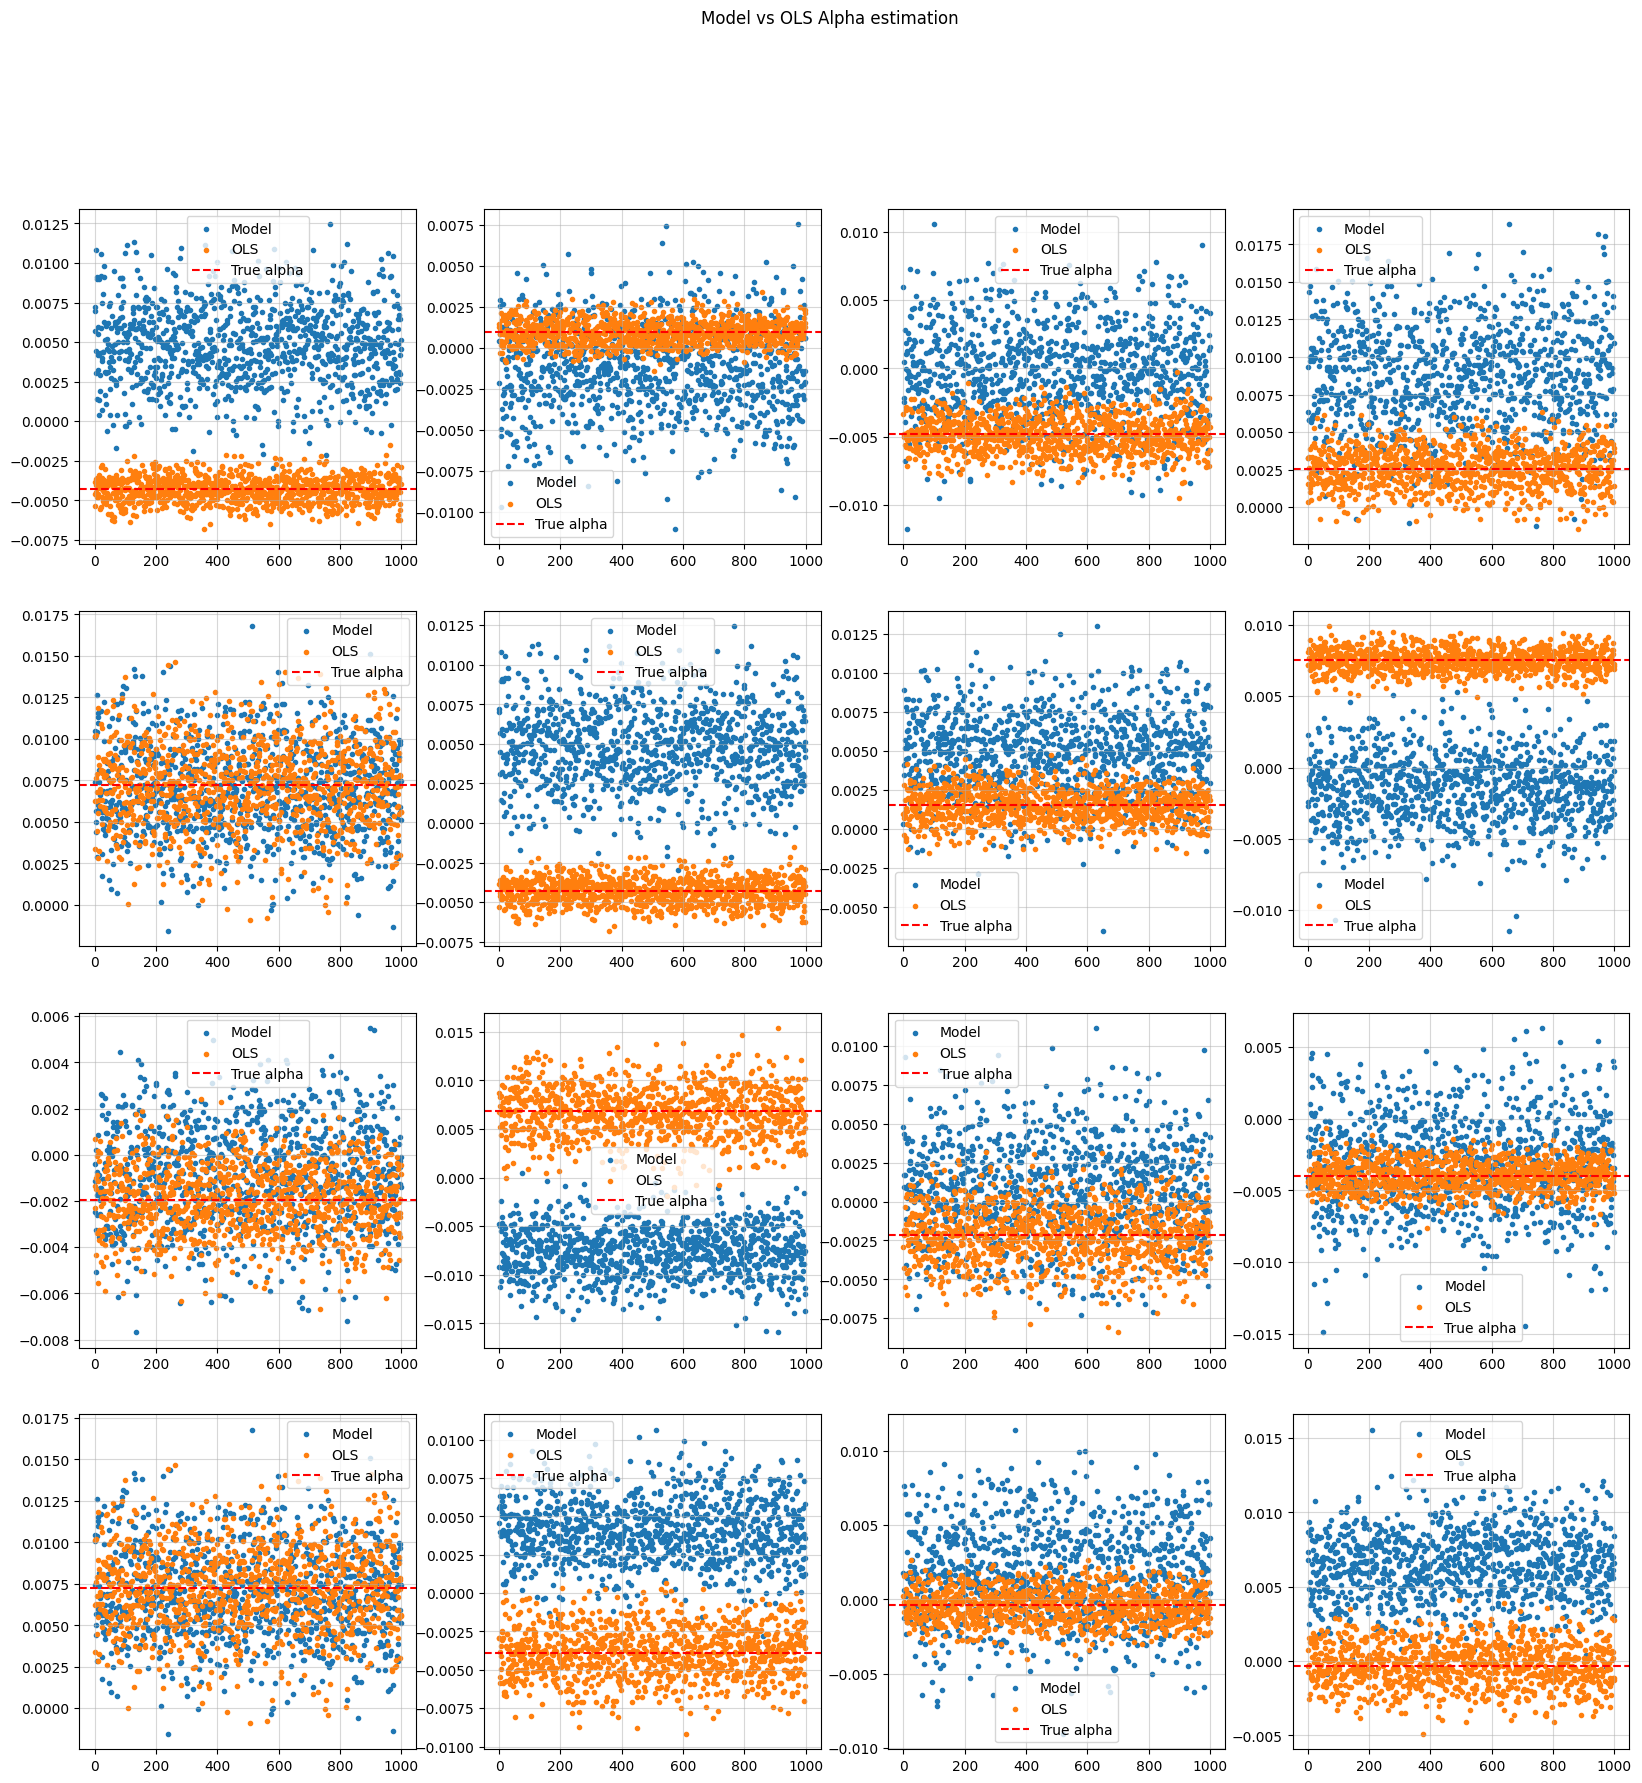

In [16]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Model vs OLS Alpha estimation')

idxs = np.random.randint(0, 99, 16)

axs = axs.flatten()
true_alphas_f = true_alphas.flatten()

for ax, idx in zip(axs, idxs):
    true_alpha = true_alphas_f[idx]
    model_alpha = model_summary['alpha'][idx]
    ols_alpha = ols_summary['alpha'][idx]

    sample = np.arange(len(model_alpha))

    ax.scatter(sample, model_alpha, label='Model', marker='.')
    ax.scatter(sample, ols_alpha, label='OLS', marker='.')
    ax.axhline(true_alpha, color='red', linestyle='--', label='True alpha')

    ax.legend()
    ax.grid(alpha=0.5)

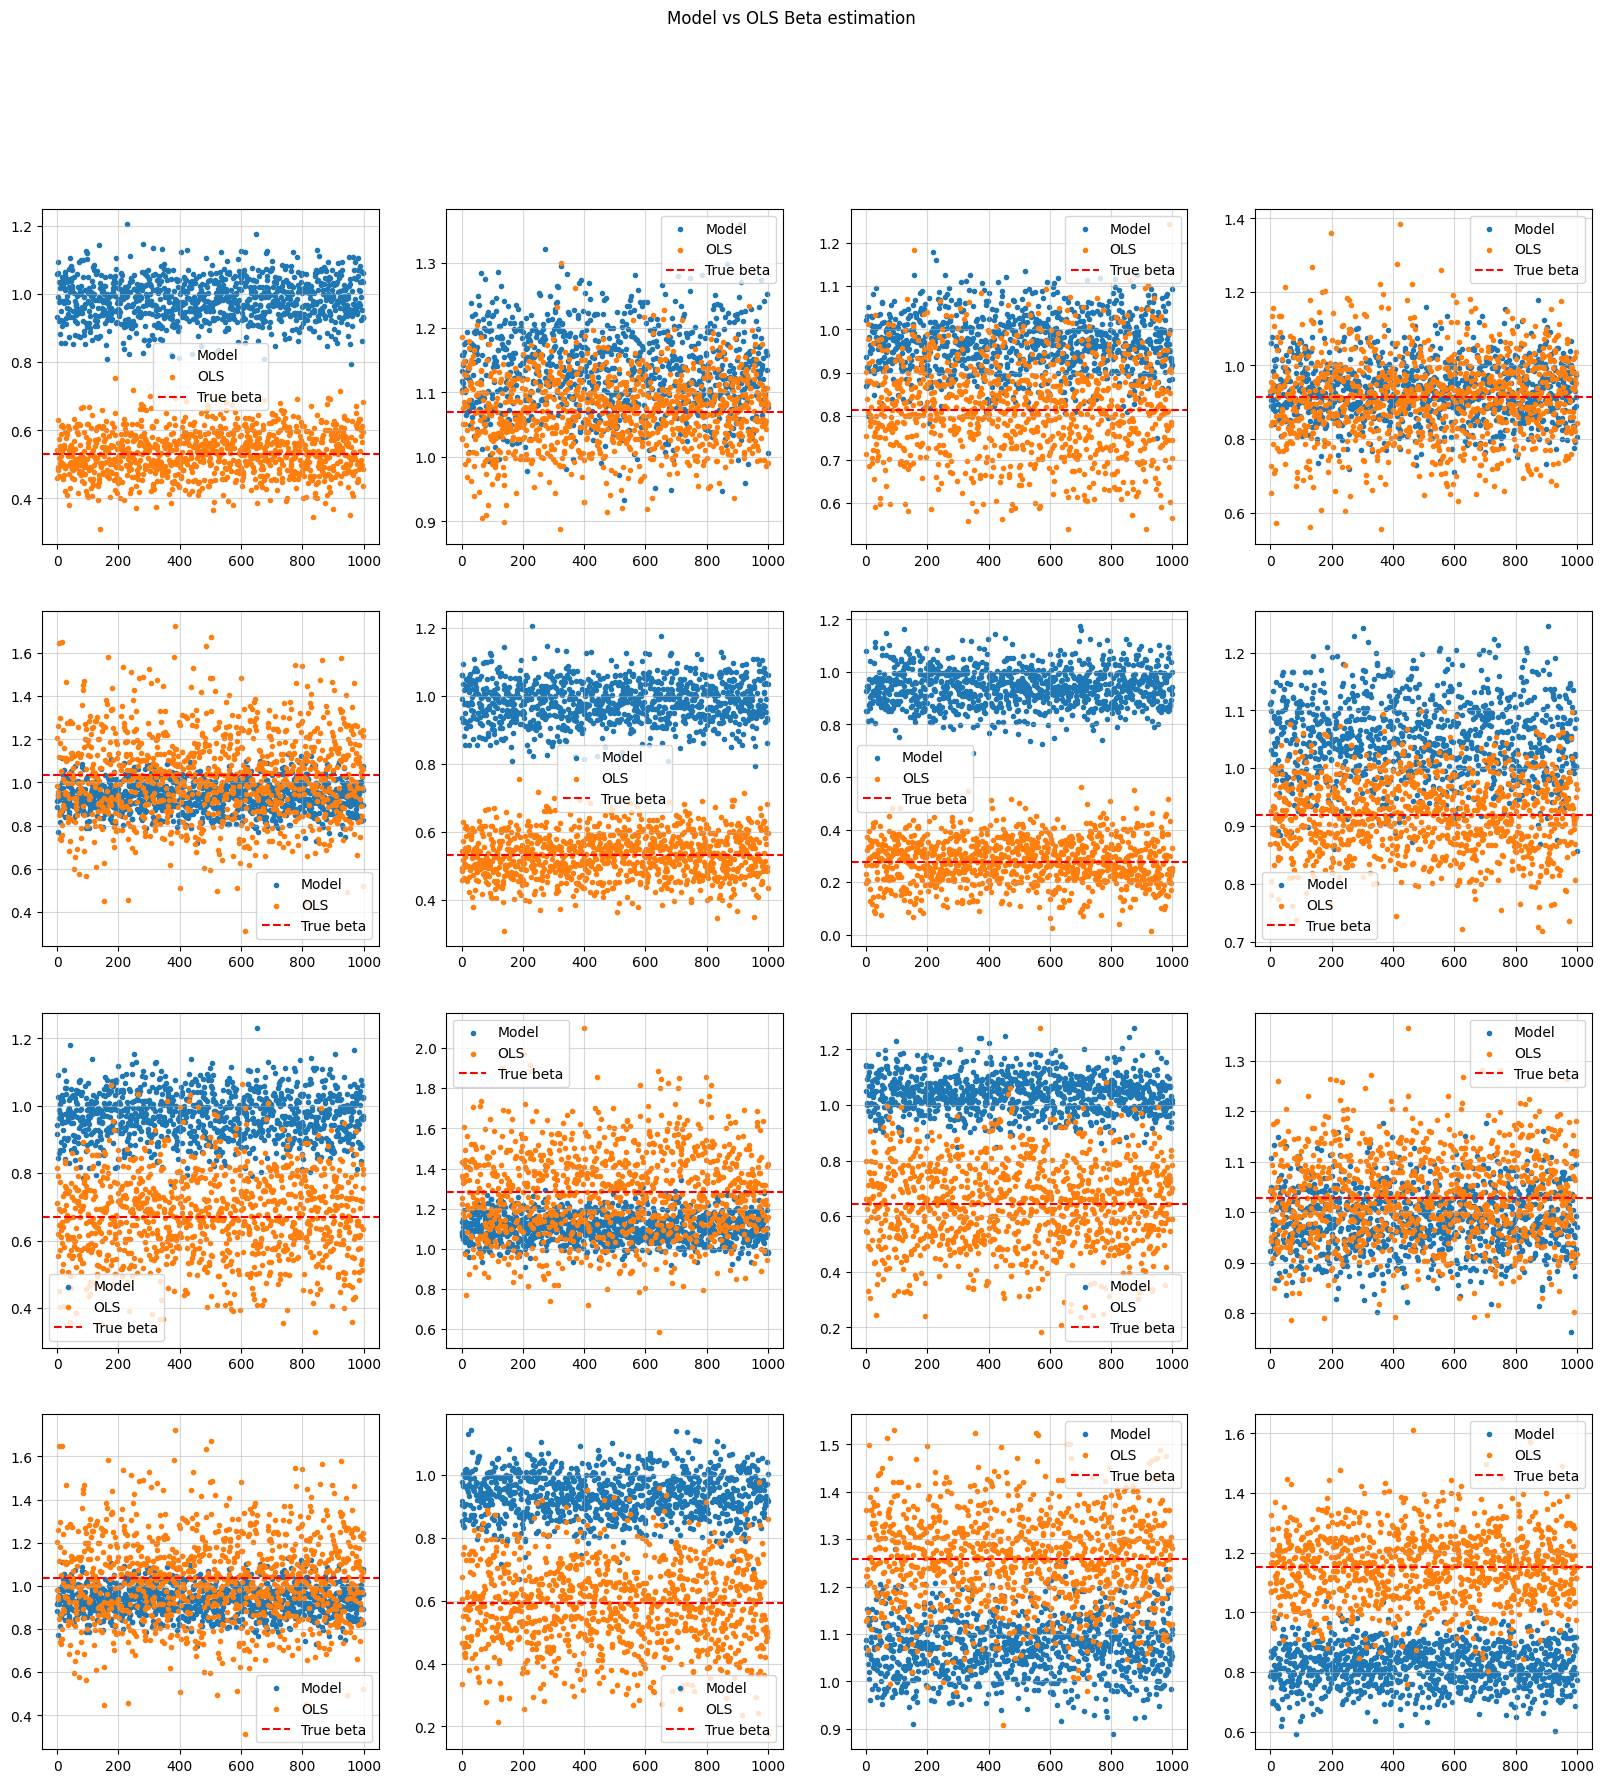

In [17]:
fig, axs = plt.subplots(4, 4, figsize=(20, 20))
fig.suptitle('Model vs OLS Beta estimation')

axs = axs.flatten()
true_betas_f = true_betas.flatten()

for ax, idx in zip(axs, idxs):
    true_beta = true_betas_f[idx]
    model_beta = model_summary['beta'][idx]
    ols_beta = ols_summary['beta'][idx]

    sample = np.arange(len(model_beta))

    ax.scatter(sample, model_beta, label='Model', marker='.')
    ax.scatter(sample, ols_beta, label='OLS', marker='.')
    ax.axhline(true_beta, color='red', linestyle='--', label='True beta')

    ax.legend()
    ax.grid(alpha=0.5)